In [ ]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

In [2]:
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

# PathMNIST

## resolution 28

In [3]:
path_perf = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_img33_crops/pathmnist/model_eval/C-1003_seed{rs}_pathmnist_28_no_resize-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/pathmnist/model_details/C-1003_seed{rs}_pathmnist_28_no_resize-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] /60)

path_perf['ResNet18'] = {}
path_perf['ResNet18']['KNN'] = np.mean(knns)
path_perf['ResNet18']['KNN_std'] = np.std(knns)
path_perf['ResNet18']['time'] = np.mean(times)
path_perf['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path_perf[f'eqResNet_N={n}'] = {}
    path_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    path_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    path_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path_perf[f'eqResNet_N={n}_flips'] = {}
    path_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    path_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    path_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    path_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path_perf[f'mixed_eqResNet_N={n}'] = {}
    path_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    path_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    path_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        if n == 8 and rs == 2:
            continue
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    path_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    path_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    path_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    path_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

path_perf_df = pd.DataFrame(path_perf).T
display(path_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.859099,0.001741,18.879508,0.191818
eqResNet_N=2,0.882219,0.003823,28.351781,1.579701
eqResNet_N=4,0.896750,0.002624,30.324830,1.428043
eqResNet_N=8,0.902321,0.001057,40.957434,0.832462
eqResNet_N=2_flips,0.887558,0.003014,27.999390,1.270527
eqResNet_N=4_flips,0.892479,0.002366,28.909077,0.645171
eqResNet_N=8_flips,0.899211,0.004516,40.416684,0.281625
mixed_eqResNet_N=2,0.879109,0.001397,21.019513,0.873884
mixed_eqResNet_N=4,0.894104,0.001440,27.597388,1.958865
mixed_eqResNet_N=8,0.895543,0.002240,28.561734,0.467450


In [ ]:
path_time = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    times = []
    for rs in range(3):
        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    path_time[f'eqResNet_N={n}'] = {}
    path_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    path_time[f'eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)


    path_time[f'mixed_eqResNet_N={n}'] = {}
    path_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    path_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

path_time_df = pd.DataFrame(path_time).T
display(path_time_df)


,time,time_std
eqResNet_N=2,28.175585,1.444262
eqResNet_N=4,29.616954,1.314863
eqResNet_N=8,40.687059,0.677684
mixed_eqResNet_N=2,21.217437,1.072603
mixed_eqResNet_N=4,26.697516,1.734421
mixed_eqResNet_N=8,28.294088,0.568100


## 128

In [ ]:
path128_perf = {}

knns = []
times = []
# Resnet (no resize)
for rs in range(3):
    eval_path = f'results_img129_crops/pathmnist/model_eval/C-1002_seed{rs}_pathmnist_128_no_resize-resnet18_100epochs_eval.pkl'
    details_path = f'results_img129_crops/pathmnist/model_details/C-1002_seed{rs}_pathmnist_128_no_resize-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / 60)

path128_perf['ResNet18'] = {}
path128_perf['ResNet18']['KNN'] = np.mean(knns)
path128_perf['ResNet18']['KNN_std'] = np.std(knns)
path128_perf['ResNet18']['time'] = np.mean(times)
path128_perf['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path128_perf[f'eqResNet_N={n}'] = {}
    path128_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    path128_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    path128_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    path128_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path128_perf[f'eqResNet_N={n}_flips'] = {}
    path128_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    path128_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    path128_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    path128_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img129_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path128_perf[f'mixed_eqResNet_N={n}'] = {}
    path128_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    path128_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    path128_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    path128_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(2):

        eval_path = f'results_img129_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img129_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    path128_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    path128_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    path128_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    path128_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    path128_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

path128_perf_df = pd.DataFrame(path128_perf).T
display(path128_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.938579,0.002447,59.157164,0.197243
eqResNet_N=2,0.937419,0.001093,111.635798,0.458857
eqResNet_N=4,0.937976,0.003316,150.826429,0.312780
eqResNet_N=8,0.932544,0.003890,279.023744,0.961385
eqResNet_N=2_flips,0.930037,0.004841,111.027278,1.153796
eqResNet_N=4_flips,0.926555,0.003185,149.562955,1.416121
eqResNet_N=8_flips,0.929991,0.006425,276.713478,4.291527
mixed_eqResNet_N=2,0.919499,0.002021,92.256890,0.267240
mixed_eqResNet_N=4,0.928552,0.001491,122.722467,0.110238
mixed_eqResNet_N=8,0.923909,0.004892,207.502199,2.744939


In [ ]:
path128_time = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img129_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    path128_time[f'eqResNet_N={n}'] = {}
    path128_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    path128_time[f'eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img129_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    path128_time[f'mixed_eqResNet_N={n}'] = {}
    path128_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    path128_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

path128_time_df = pd.DataFrame(path128_time).T
display(path128_time_df)


,time,time_std
eqResNet_N=2,111.331538,0.929232
eqResNet_N=4,150.194692,1.204453
eqResNet_N=8,277.868611,3.317388
mixed_eqResNet_N=2,92.378418,0.255300
mixed_eqResNet_N=4,122.220879,1.060237
mixed_eqResNet_N=8,207.247498,2.854398


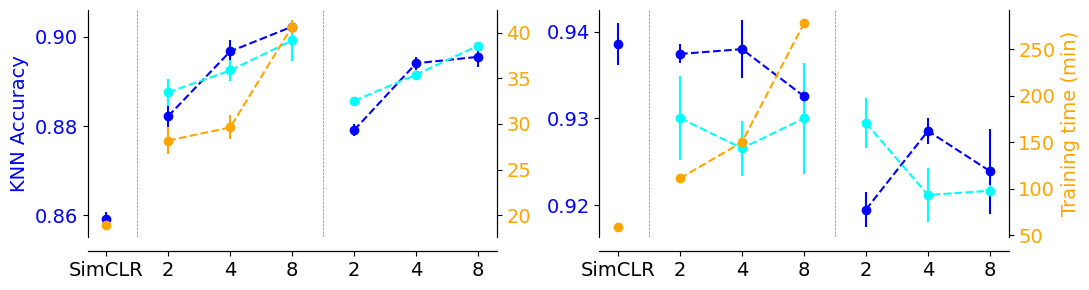

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3)) # , gridspec_kw={'wspace': 0.4}
fontsize = 14

data = {
    28: {'perf': path_perf, 'time': path_time},
    128: {'perf': path128_perf, 'time': path128_time}
}

labels = [f'N={n}' for n in [2, 4, 8]] 

x_resnet = np.array([0])
x_eqresnet = np.array([1, 2, 3])
x_mixed = np.array([4, 5, 6])

for i, size in enumerate(data.keys()):
    data_perf = data[size]['perf']
    data_time = data[size]['time']

    # Resnet
    ax[i].errorbar(
        x_resnet,
        data_perf[f'ResNet18']['KNN'],
        yerr=data_perf[f'ResNet18']['KNN_std'],
        fmt='--o',
        color='blue',
        zorder=-1,
        clip_on=False,
    )
    ax[i].axvline(0.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black')

    # eqCLR rot
    ax[i].errorbar(
        x_eqresnet,
        [data_perf[f'eqResNet_{label}']['KNN'] for label in labels],
        yerr=[data_perf[f'eqResNet_{label}']['KNN_std'] for label in labels],
        fmt='--o',
        color='blue',
        label='KNN rotations',
        clip_on=False,
    )

    # eqCLR fips+rot
    ax[i].errorbar(
        x_eqresnet,
        [data_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels],
        yerr=[data_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels],
        fmt='--o',
        color='cyan',
        label='KNN flips + rotations',
        clip_on=False,
    )
    ax[i].axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black')

    # mixed eqCLR rot
    ax[i].errorbar(
        x_mixed,
        [data_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels],
        yerr=[data_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels],
        fmt='--o',
        color='blue',
        clip_on=False,
    )
    # mixed eqCLR flips
    ax[i].errorbar(
        x_mixed,
        [data_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels],
        yerr=[data_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels],
        fmt='--o',
        color='cyan',
        clip_on=False,
    )

    ax[i].set_xticks(
        list(x_resnet) + list(x_eqresnet) + list(x_mixed)
    )
    ax[i].set_xticklabels(
        ['SimCLR', 2, 4, 8, 2, 4, 8]
    )
    if size == 28:
        ax[i].set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
    ax[i].tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
    # ax.set_ylim(0.79, 0.89)
    # ax.set_yticks([0.79, 0.81, 0.83, 0.85, 0.87, 0.89])

    # time axis
    ax2 = ax[i].twinx()
    ax2.errorbar(
        x_resnet,
        data_perf[f'ResNet18']['time'],
        yerr=data_perf[f'ResNet18']['time_std'],
        fmt='--o',
        color='orange',
        zorder=-1,
        clip_on=False,
    )

    ax2.errorbar(
        x_eqresnet,
        [data_time[f'eqResNet_{label}']['time'] for label in labels],
        yerr=[data_time[f'eqResNet_{label}']['time_std'] for label in labels],
        fmt='--o',
        color='orange',
        clip_on=False,
    )

    if size == 128:
        ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)

    ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
    ax[i].spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax[i].tick_params(axis='x', labelsize=fontsize)
    ax[i].spines['bottom'].set_position(('outward', 10))
    ax2.spines['bottom'].set_position(('outward', 10))

plt.tight_layout()
    # ax[i].text(2, ax[i].get_ylim()[0] - 0.014, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
    # ax[i].text(5, ax[i].get_ylim()[0] - 0.014, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)


## all metrics 28

In [ ]:
path_perf_all = {}

# Resnet
path_perf_all['SimCLR'] = {}
for rs in range(3):
    eval_path = f'results_img33_crops/pathmnist/model_eval/C-1003_seed{rs}_pathmnist_28_no_resize-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/pathmnist/model_details/C-1003_seed{rs}_pathmnist_28_no_resize-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)
    
    path_perf_all['SimCLR'][f'seed{rs}'] = eval
    path_perf_all['SimCLR'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR
for n in [2, 4, 8]:
    path_perf_all[f'eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = eval
        path_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    path_perf_all[f'eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0001_seed{rs}_pathmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}'] = eval
        path_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR
for n in [4, 8]:
    path_perf_all[f'mixed eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}'] = eval
        path_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR flips
for n in [4, 8]:
    path_perf_all[f'mixed eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/model_eval/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_eval.pkl'
        details_path = f'results_img33_crops/pathmnist/model_details/C-0002_seed{rs}_pathmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}'] = eval
        path_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60


In [ ]:
path_perf_mean = {}

for model_name, seeds in path_perf_all.items():
    path_perf_mean[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        path_perf_mean[model_name][eval_key] = float(np.mean(values))

path_perf_mean_df = pd.DataFrame(path_perf_mean).T
display(path_perf_mean_df)

,euclidean,cosine,logistic_regression,linear_accuracy,linear_accuracy_rep,linear_accuracy_aug,time
SimCLR,0.859099,0.861421,0.868895,0.866063,0.866574,0.864485,18.879508
eqCLR $C_2$,0.882219,0.881616,0.890529,0.888904,0.889090,0.890994,28.351781
eqCLR $C_4$,0.896750,0.895311,0.905803,0.905617,0.904410,0.906778,30.324830
eqCLR $C_8$,0.902321,0.901439,0.909424,0.907242,0.907939,0.905989,40.957434
eqCLR $D_2$,0.887558,0.885376,0.895357,0.893872,0.893315,0.894336,27.999390
eqCLR $D_4$,0.892479,0.891736,0.898654,0.897679,0.896657,0.900743,28.909077
eqCLR $D_8$,0.899211,0.898282,0.907196,0.904735,0.905803,0.906221,40.416684
mixed eqCLR $C_4$,0.894104,0.892247,0.904410,0.900046,0.902786,0.904968,27.597388
mixed eqCLR $C_8$,0.895543,0.894336,0.907010,0.903018,0.905014,0.908403,28.561734
mixed eqCLR $D_4$,0.891551,0.890715,0.899489,0.895590,0.897400,0.901346,25.797644


# DermaMNIST

## 28

In [ ]:
derma_perf = {}

# Resnet (no resize)
knns = []
times = []
for rs in range(3):
    eval_path = f'results_img33/dermamnist/model_eval/1001_seed{rs}_resnet18_dermamnist_no_resize_100epochs_eval.pkl'
    details_path = f'results_img33/dermamnist/model_details/1001_seed{rs}_resnet18_dermamnist_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / 60)

derma_perf['ResNet18'] = {}
derma_perf['ResNet18']['KNN'] = np.mean(knns)
derma_perf['ResNet18']['KNN_std'] = np.std(knns)
derma_perf['ResNet18']['time'] = np.mean(times)
derma_perf['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma_perf[f'eqResNet_N={n}'] = {}
    derma_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    derma_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    derma_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma_perf[f'eqResNet_N={n}_flips'] = {}
    derma_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    derma_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    derma_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    derma_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
                details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma_perf[f'mixed_eqResNet_N={n}'] = {}
    derma_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    derma_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    derma_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'


        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    derma_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    derma_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    derma_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    derma_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

derma_perf_df = pd.DataFrame(derma_perf).T
display(derma_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.704738,0.004252,2.601726,0.051504
eqResNet_N=2,0.703408,0.002316,4.289676,0.340323
eqResNet_N=4,0.710391,0.003292,4.642370,0.200884
eqResNet_N=8,0.708396,0.004316,5.766925,0.154136
eqResNet_N=2_flips,0.704073,0.004079,4.509070,0.147029
eqResNet_N=4_flips,0.711222,0.005325,4.744280,0.149105
eqResNet_N=8_flips,0.709726,0.003232,5.809828,0.097005
mixed_eqResNet_N=2,0.704904,0.005934,3.203521,0.060641
mixed_eqResNet_N=4,0.703574,0.002009,4.116959,0.154965
mixed_eqResNet_N=8,0.703242,0.002670,4.630632,0.163270


In [ ]:
derma_time = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    derma_time[f'eqResNet_N={n}'] = {}
    derma_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    derma_time[f'eqResNet_N={n}']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'
        
        with open(details_path1, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path1 = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    derma_time[f'mixed_eqResNet_N={n}'] = {}
    derma_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    derma_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

derma_time_df = pd.DataFrame(derma_time).T
display(derma_time_df)


,time,time_std
eqResNet_N=2,4.399373,0.284169
eqResNet_N=4,4.693325,0.184092
eqResNet_N=8,5.788377,0.130553
mixed_eqResNet_N=2,3.216989,0.051463
mixed_eqResNet_N=4,4.171726,0.146458
mixed_eqResNet_N=8,4.646542,0.127574


## 128

In [ ]:
derma128_perf = {}

# Resnet (no resize)
knns = []
times = []
for rs in range(3):
    eval_path = f'results_img129_crops/dermamnist/model_eval/C-1001_seed{rs}_resnet18_dermamnist_128_no_resize_100epochs_eval.pkl'
    details_path = f'results_img129_crops/dermamnist/model_details/C-1001_seed{rs}_resnet18_dermamnist_128_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / 60)

derma128_perf['ResNet18'] = {}
derma128_perf['ResNet18']['KNN'] = np.mean(knns)
derma128_perf['ResNet18']['KNN_std'] = np.std(knns)
derma128_perf['ResNet18']['time'] = np.mean(times)
derma128_perf['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma128_perf[f'eqResNet_N={n}'] = {}
    derma128_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma128_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    derma128_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    derma128_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma128_perf[f'eqResNet_N={n}_flips'] = {}
    derma128_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    derma128_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    derma128_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    derma128_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'
   
        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma128_perf[f'mixed_eqResNet_N={n}'] = {}
    derma128_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma128_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    derma128_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    derma128_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    derma128_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    derma128_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    derma128_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    derma128_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    derma128_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

derma128_perf_df = pd.DataFrame(derma128_perf).T
display(derma128_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.718537,0.002050,9.226919,0.039569
eqResNet_N=2,0.738820,0.007081,14.695683,0.246216
eqResNet_N=4,0.733832,0.004858,17.866497,0.076675
eqResNet_N=8,0.735495,0.004755,27.359611,0.236539
eqResNet_N=2_flips,0.736160,0.005915,14.843978,0.122808
eqResNet_N=4_flips,0.728678,0.010533,17.780501,0.179430
eqResNet_N=8_flips,0.736326,0.004976,27.224622,0.177105
mixed_eqResNet_N=2,0.735495,0.003913,12.150296,0.148680
mixed_eqResNet_N=4,0.733001,0.001695,15.759886,0.174481
mixed_eqResNet_N=8,0.738653,0.003232,22.209906,0.177374


In [ ]:
derma128_time = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)
        
        details_path = f'results_img129_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    derma128_time[f'eqResNet_N={n}'] = {}
    derma128_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    derma128_time[f'eqResNet_N={n}']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path1 = f'results_img129_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'


        with open(details_path, 'rb') as f:
                details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    derma128_time[f'mixed_eqResNet_N={n}'] = {}
    derma128_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    derma128_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

derma128_time_df = pd.DataFrame(derma128_time).T
display(derma128_time_df)


,time,time_std
eqResNet_N=2,14.769830,0.208206
eqResNet_N=4,17.823499,0.144519
eqResNet_N=8,27.292117,0.219577
mixed_eqResNet_N=2,12.214371,0.127788
mixed_eqResNet_N=4,15.702098,0.153588
mixed_eqResNet_N=8,22.133068,0.195674


## all metrics 28

In [73]:
derma_perf_all = {}

# Resnet
derma_perf_all['SimCLR'] = {}
for rs in range(3):
    eval_path = f'results_img33/dermamnist/model_eval/1001_seed{rs}_resnet18_dermamnist_no_resize_100epochs_eval.pkl'
    details_path = f'results_img33/dermamnist/model_details/1001_seed{rs}_resnet18_dermamnist_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    derma_perf_all['SimCLR'][f'seed{rs}'] = eval
    derma_perf_all['SimCLR'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR
for n in [2, 4, 8]:
    derma_perf_all[f'eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = eval
        derma_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    derma_perf_all[f'eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0001_seed{rs}_dermamnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}'] = eval
        derma_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR
for n in [4, 8]:
    derma_perf_all[f'mixed eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}'] = eval
        derma_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR flips
for n in [4, 8]:
    derma_perf_all[f'mixed eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/model_eval/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/dermamnist/model_details/C-0002_seed{rs}_dermamnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}'] = eval
        derma_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

In [74]:
derma_perf_mean = {}

for model_name, seeds in derma_perf_all.items():
    derma_perf_mean[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        derma_perf_mean[model_name][eval_key] = float(np.mean(values))

derma_perf_mean_df = pd.DataFrame(derma_perf_mean).T
display(derma_perf_mean_df)

,euclidean,cosine,logistic_regression,linear_accuracy,linear_accuracy_rep,linear_accuracy_aug,time
SimCLR,0.704738,0.701746,0.713051,0.729510,0.728346,0.706899,2.601726
eqCLR $C_2$,0.703408,0.703076,0.719202,0.725353,0.721862,0.717872,4.289676
eqCLR $C_4$,0.710391,0.707066,0.727681,0.726850,0.724356,0.717041,4.642370
eqCLR $C_8$,0.708396,0.710058,0.724190,0.722028,0.721031,0.718204,5.766925
eqCLR $D_2$,0.704073,0.704073,0.721696,0.723691,0.725021,0.716708,4.509070
eqCLR $D_4$,0.711222,0.709393,0.720698,0.722361,0.723525,0.718038,4.744280
eqCLR $D_8$,0.709726,0.707066,0.728678,0.727681,0.724855,0.717207,5.809828
mixed eqCLR $C_4$,0.703574,0.701413,0.733832,0.731172,0.731172,0.718703,4.116959
mixed eqCLR $C_8$,0.703242,0.703242,0.729011,0.730840,0.731338,0.712884,4.630632
mixed eqCLR $D_4$,0.705736,0.705403,0.730673,0.731837,0.726517,0.712718,4.226493


Text(9.5, 0.6884898938358417, 'mixed eqCLR\n(rot+flips)')

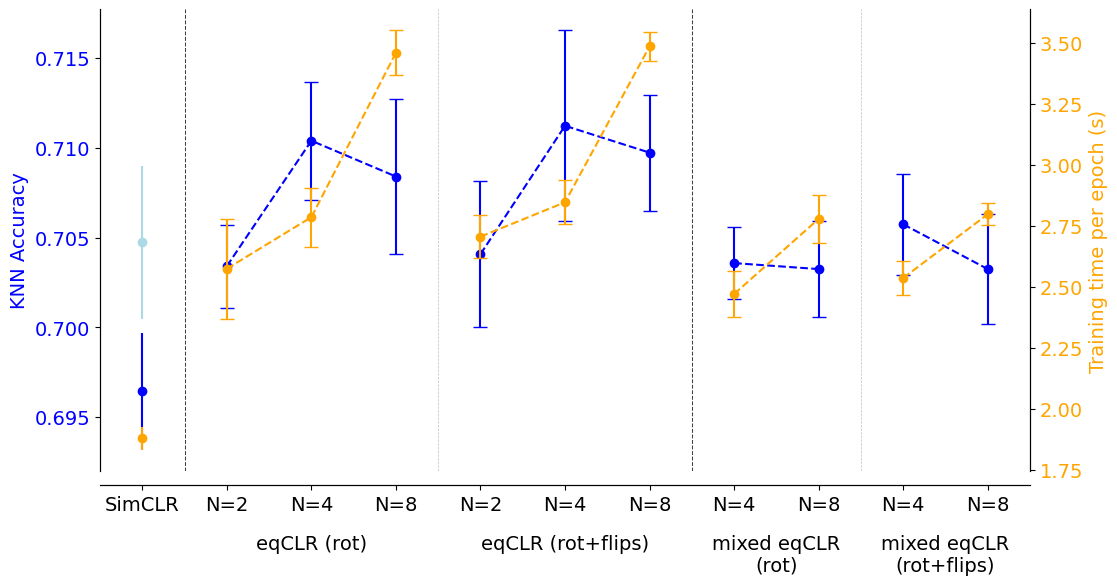

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
fontsize = 14

labels_eq = ['N=2', 'N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2, 3])
x_eq2 = np.array([4, 5, 6])
x_mixed1 = np.array([7, 8])
x_mixed2 = np.array([9, 10])

# ResNet18
ax.errorbar(
    x_resnet,
    derma_perf['ResNet18']['KNN'],
    yerr=derma_perf['ResNet18']['KNN_std'],
    fmt='o',
    color='blue'
)
# ResNet18 (no resize)
ax.errorbar(
    x_resnet,
    derma_perf['ResNet18 (no resize)']['KNN'],
    yerr=derma_perf['ResNet18 (no resize)']['KNN_std'],
    fmt='o',
    color='lightblue',
    zorder=-1
)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet rot
ax.errorbar(
    x_eq1,
    [derma_perf[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[derma_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_eq2,
    [derma_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_eq],
    yerr=[derma_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(6.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot
ax.errorbar(
    x_mixed1,
    [derma_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[derma_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(8.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed2,
    [derma_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_mixed],
    yerr=[derma_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    [x_resnet] + list(x_eq1) + list(x_eq2) + list(x_mixed1) + list(x_mixed2)
)

ax.set_xticklabels(
    ['SimCLR'] + labels_eq + labels_eq + labels_mixed + labels_mixed
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
# ax.set_ylim(0.86, 0.9)
# ax.set_yticks([0.86, 0.87, 0.88, 0.89, 0.9])
# ax.set_xlabel('Group order', fontsize=fontsize)

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    derma_perf['ResNet18']['time'],
    yerr=derma_perf['ResNet18']['time_std'],
    fmt='o',
    color='orange'
)

# eqResNet rot
ax2.errorbar(
    x_eq1,
    [derma_perf[f'eqResNet_{label}']['time'] for label in labels_eq],
    yerr=[derma_perf[f'eqResNet_{label}']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# eqResNet rot+flips
ax2.errorbar(
    x_eq2,
    [derma_perf[f'eqResNet_{label}_flips']['time'] for label in labels_eq],
    yerr=[derma_perf[f'eqResNet_{label}_flips']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed1,
    [derma_perf[f'mixed_eqResNet_{label}']['time'] for label in labels_mixed],
    yerr=[derma_perf[f'mixed_eqResNet_{label}']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot+flips
ax2.errorbar(
    x_mixed2,
    [derma_perf[f'mixed_eqResNet_{label}_flips']['time'] for label in labels_mixed],
    yerr=[derma_perf[f'mixed_eqResNet_{label}_flips']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
#ax2.set_ylim(5, 40)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

ax.text(2, ax.get_ylim()[0] - 0.0035, "eqCLR (rot)", ha='center', va='top', fontsize=fontsize)
ax.text(5, ax.get_ylim()[0] - 0.0035, "eqCLR (rot+flips)", ha='center', va='top', fontsize=fontsize)
ax.text(7.5, ax.get_ylim()[0] - 0.0035, "mixed eqCLR\n(rot)", ha='center', va='top', fontsize=fontsize)
ax.text(9.5, ax.get_ylim()[0] - 0.0035, "mixed eqCLR\n(rot+flips)", ha='center', va='top', fontsize=fontsize)

# BloodMNIST

## Small run

In [ ]:
blood_perf = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_img33_crops/bloodmnist/model_eval/C-1005_seed{rs}_resnet18_bloodmnist_33_100epochs_eval.pkl'
    details_path = f'results_img33_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_33_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

blood_perf['ResNet18'] = {}
blood_perf['ResNet18']['KNN'] = np.mean(knns)
blood_perf['ResNet18']['KNN_std'] = np.std(knns)
blood_perf['ResNet18']['time'] = np.mean(times)
blood_perf['ResNet18']['time_std'] = np.std(times)

# Resnet (no resize)
knns = []
times = []
for rs in range(3):
    eval_path = f'results_img33/bloodmnist/model_eval/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_eval.pkl'
    details_path = f'results_img33/bloodmnist/model_details/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

blood_perf['ResNet18 (no resize)'] = {}
blood_perf['ResNet18 (no resize)']['KNN'] = np.mean(knns)
blood_perf['ResNet18 (no resize)']['KNN_std'] = np.std(knns)
blood_perf['ResNet18 (no resize)']['time'] = np.mean(times)
blood_perf['ResNet18 (no resize)']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        if n == 8 and rs == 2:
            continue
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    blood_perf[f'eqResNet_N={n}'] = {}
    blood_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    blood_perf[f'eqResNet_N={n}_flips'] = {}
    blood_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    blood_perf[f'mixed_eqResNet_N={n}'] = {}
    blood_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])

    blood_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    blood_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

blood_perf_df = pd.DataFrame(blood_perf).T
display(blood_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.820325,0.006573,2.607792,0.010652
ResNet18 (no resize),0.821495,0.002414,2.401514,0.055389
eqResNet_N=2,0.852285,0.006564,3.578440,0.265550
eqResNet_N=4,0.870213,0.000239,3.980763,0.015547
eqResNet_N=8,0.870944,0.001023,5.150841,0.024738
eqResNet_N=2_flips,0.855305,0.003532,3.784195,0.007730
eqResNet_N=4_flips,0.873429,0.001329,4.025215,0.015806
eqResNet_N=8_flips,0.872162,0.011052,5.146036,0.021608
mixed_eqResNet_N=4,0.857254,0.010278,3.455379,0.018351
mixed_eqResNet_N=8,0.864465,0.004655,3.938619,0.027890


In [56]:
blood_perf_all = {}

# Resnet (no resize)
blood_perf_all['SimCLR'] = {}
for rs in range(3):
    eval_path = f'results_img33/bloodmnist/model_eval/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_eval.pkl'
    details_path = f'results_img33/bloodmnist/model_details/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    blood_perf_all['SimCLR'][f'seed{rs}'] = eval
    blood_perf_all['SimCLR'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR
for n in [2, 4, 8]:
    blood_perf_all[f'eqCLR $C_{n}$'] = {}
    for rs in range(3):
        if n == 8 and rs == 2:
            continue
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = eval
        blood_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    blood_perf_all[f'eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}'] = eval
        blood_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60


# mixed equivariant SimCLR
for n in [4, 8]:
    blood_perf_all[f'mixed eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}'] = eval
        blood_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR flips
for n in [4, 8]:
    blood_perf_all[f'mixed eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}'] = eval
        blood_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60



In [57]:
blood_perf_mean = {}

for model_name, seeds in blood_perf_all.items():
    blood_perf_mean[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        blood_perf_mean[model_name][eval_key] = float(np.mean(values))

blood_perf_mean_df = pd.DataFrame(blood_perf_mean).T
display(blood_perf_mean_df)

,euclidean,cosine,logistic_regression,linear_accuracy,linear_accuracy_rep,linear_accuracy_aug,time
SimCLR,0.821495,0.821105,0.851311,0.849459,0.848290,0.821787,4.002523
eqCLR $C_2$,0.857547,0.854526,0.894865,0.891455,0.879567,0.860470,5.529796
eqCLR $C_4$,0.870213,0.869434,0.904901,0.904316,0.893988,0.880737,6.634605
eqCLR $C_8$,0.870944,0.867144,0.894914,0.892429,0.883367,0.872552,8.584735
eqCLR $D_2$,0.855305,0.851213,0.893501,0.888921,0.879665,0.866901,6.306991
eqCLR $D_4$,0.873429,0.868557,0.902563,0.901881,0.893111,0.884537,6.708692
eqCLR $D_8$,0.872162,0.869726,0.905388,0.904804,0.890480,0.888239,8.576726
mixed eqCLR $C_4$,0.857254,0.854429,0.906460,0.899834,0.887460,0.871480,5.758965
mixed eqCLR $C_8$,0.864465,0.862321,0.907922,0.899932,0.890773,0.876352,6.564365
mixed eqCLR $D_4$,0.851603,0.852577,0.899445,0.892819,0.882588,0.864757,5.792170


Text(9.5, 0.8002798604908556, 'mixed eqCLR\n(rot+flips)')

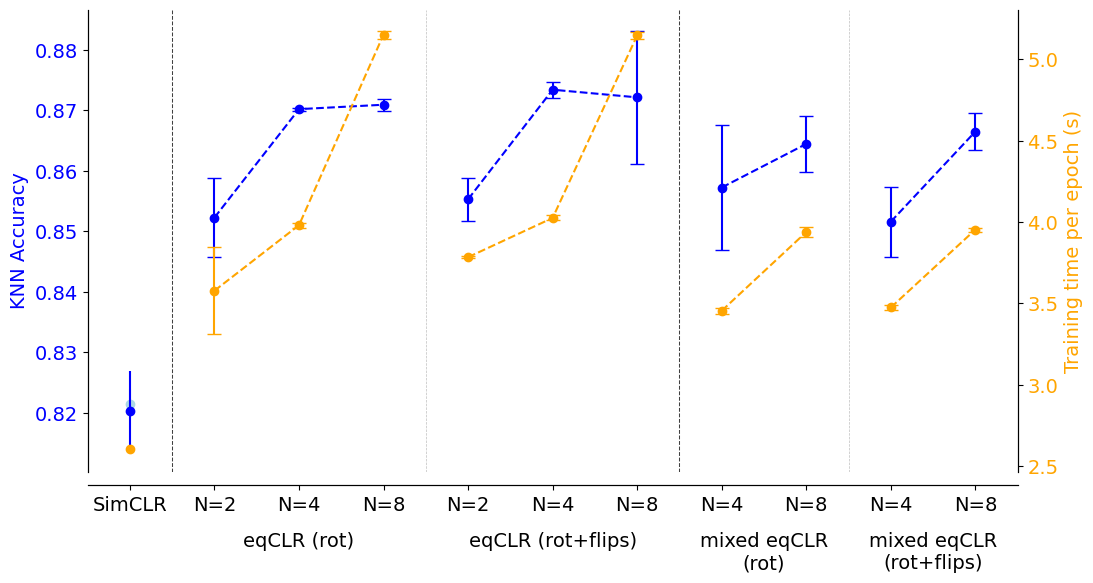

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
fontsize = 14

labels_eq = ['N=2', 'N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2, 3])
x_eq2 = np.array([4, 5, 6])
x_mixed1 = np.array([7, 8])
x_mixed2 = np.array([9, 10])

# ResNet18
ax.errorbar(
    x_resnet,
    blood_perf['ResNet18']['KNN'],
    yerr=blood_perf['ResNet18']['KNN_std'],
    fmt='o',
    color='blue'
)
# ResNet18 (no resize)
ax.errorbar(
    x_resnet,
    blood_perf['ResNet18 (no resize)']['KNN'],
    yerr=blood_perf['ResNet18 (no resize)']['KNN_std'],
    fmt='o',
    color='lightblue',
    zorder=-1
)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet rot
ax.errorbar(
    x_eq1,
    [blood_perf[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[blood_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_eq2,
    [blood_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_eq],
    yerr=[blood_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(6.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot
ax.errorbar(
    x_mixed1,
    [blood_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[blood_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(8.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed2,
    [blood_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_mixed],
    yerr=[blood_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    [x_resnet] + list(x_eq1) + list(x_eq2) + list(x_mixed1) + list(x_mixed2)
)

ax.set_xticklabels(
    ['SimCLR'] + labels_eq + labels_eq + labels_mixed + labels_mixed
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
# ax.set_ylim(0.86, 0.9)
# ax.set_yticks([0.86, 0.87, 0.88, 0.89, 0.9])
# ax.set_xlabel('Group order', fontsize=fontsize)

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    blood_perf['ResNet18']['time'],
    yerr=blood_perf['ResNet18']['time_std'],
    fmt='o',
    color='orange'
)

# eqResNet rot
ax2.errorbar(
    x_eq1,
    [blood_perf[f'eqResNet_{label}']['time'] for label in labels_eq],
    yerr=[blood_perf[f'eqResNet_{label}']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# eqResNet rot+flips
ax2.errorbar(
    x_eq2,
    [blood_perf[f'eqResNet_{label}_flips']['time'] for label in labels_eq],
    yerr=[blood_perf[f'eqResNet_{label}_flips']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed1,
    [blood_perf[f'mixed_eqResNet_{label}']['time'] for label in labels_mixed],
    yerr=[blood_perf[f'mixed_eqResNet_{label}']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot+flips
ax2.errorbar(
    x_mixed2,
    [blood_perf[f'mixed_eqResNet_{label}_flips']['time'] for label in labels_mixed],
    yerr=[blood_perf[f'mixed_eqResNet_{label}_flips']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
#ax2.set_ylim(5, 40)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

ax.text(2, ax.get_ylim()[0] - 0.01, "eqCLR (rot)", ha='center', va='top', fontsize=fontsize)
ax.text(5, ax.get_ylim()[0] - 0.01, "eqCLR (rot+flips)", ha='center', va='top', fontsize=fontsize)
ax.text(7.5, ax.get_ylim()[0] - 0.01, "mixed eqCLR\n(rot)", ha='center', va='top', fontsize=fontsize)
ax.text(9.5, ax.get_ylim()[0] - 0.01, "mixed eqCLR\n(rot+flips)", ha='center', va='top', fontsize=fontsize)

## Big sweep

In [11]:
blood_perf = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_img33_crops/bloodmnist/model_eval/C-1005_seed{rs}_resnet18_bloodmnist_33_100epochs_eval.pkl'
    details_path = f'results_img33_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_33_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['cosine'][10])
    times.append(details['Training time w/o evaluation'] / 60)

blood_perf['ResNet18'] = {}
blood_perf['ResNet18']['KNN'] = np.mean(knns)
blood_perf['ResNet18']['KNN_std'] = np.std(knns)
blood_perf['ResNet18']['time'] = np.mean(times)
blood_perf['ResNet18']['time_std'] = np.std(times)

# Resnet
for rs in range(3):
    knns = []
    times = []
    for epoch in [150, 200, 250]:
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-1005_seed{rs}_resnet18_bloodmnist_28_no_resize_{epoch}epochs_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_28_no_resize_{epoch}epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['cosine'][10])
        times.append(details['Training time w/o evaluation'] / 60)

        blood_perf[f'ResNet18_{epoch}e'] = {}
        blood_perf[f'ResNet18_{epoch}e']['KNN'] = np.mean(knns)
        blood_perf[f'ResNet18_{epoch}e']['KNN_std'] = np.std(knns)
        blood_perf[f'ResNet18_{epoch}e']['time'] = np.mean(times)
        blood_perf[f'ResNet18_{epoch}e']['time_std'] = np.std(times)

# Resnet (no resize)
knns = []
times = []
for rs in range(3):
    eval_path = f'results_img33/bloodmnist/model_eval/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_eval.pkl'
    details_path = f'results_img33/bloodmnist/model_details/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['cosine'][10])
    times.append(details['Training time w/o evaluation'] / 60)

blood_perf['ResNet18_100e'] = {}
blood_perf['ResNet18_100e']['KNN'] = np.mean(knns)
blood_perf['ResNet18_100e']['KNN_std'] = np.std(knns)
blood_perf['ResNet18_100e']['time'] = np.mean(times)
blood_perf['ResNet18_100e']['time_std'] = np.std(times)

# equivariant SimCLR
for n in range(1, 15):
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['cosine'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf[f'eqResNet_N={n}'] = {}
    blood_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in range(2, 15, 2):
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['cosine'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf[f'eqResNet_N={n}_flips'] = {}
    blood_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in range(1, 15):
    knns = []
    times = []

    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['cosine'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf[f'mixed_eqResNet_N={n}'] = {}
    blood_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in range(2, 15, 2):
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/model_eval/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['cosine'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    blood_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

blood_perf_df = pd.DataFrame(blood_perf).T
display(blood_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.820520,0.004223,4.346319,0.017753
ResNet18_150e,0.848582,0.000000,5.819594,0.000000
ResNet18_200e,0.854867,0.006285,6.891695,1.072102
ResNet18_250e,0.861639,0.010865,7.950520,1.734499
ResNet18_100e,0.821105,0.002302,4.002523,0.092316
eqResNet_N=1,0.827049,0.005444,5.405473,0.596857
eqResNet_N=2,0.854526,0.010208,5.529796,0.154835
eqResNet_N=3,0.852090,0.007224,6.658770,0.346075
eqResNet_N=4,0.869434,0.002574,6.634605,0.025911
eqResNet_N=5,0.866024,0.002847,7.860121,0.309638


In [12]:
combined_time = {}

# Resnet (no resize)
times = []
for rs in range(3):
    details_path = f'results_img33/bloodmnist/model_details/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_details.pkl'

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    times.append(details['Training time w/o evaluation'] / 60)

combined_time['ResNet18_100e'] = {}
combined_time['ResNet18_100e']['time'] = np.mean(times)
combined_time['ResNet18_100e']['time_std'] = np.std(times)

# Resnet (more epochs)
for rs in range(3):
    times = []
    for epoch in [150, 200, 250]:
        details_path = f'results_img33_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_28_no_resize_{epoch}epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        combined_time[f'ResNet18_{epoch}e'] = {}
        combined_time[f'ResNet18_{epoch}e']['time'] = np.mean(times)
        combined_time[f'ResNet18_{epoch}e']['time_std'] = np.std(times)

# equivariant SimCLR
for n in range(1, 15):
    times = []
    for rs in range(3):
        details_path_rot = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'
        with open(details_path_rot, 'rb') as f:
            details_rot = pickle.load(f)
        times.append(details_rot['Training time w/o evaluation'] / 60)
        
        if n in list(range(2, 15, 2)):
            details_path_flip = f'results_img33_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'
            with open(details_path_flip, 'rb') as f:
                details_flip = pickle.load(f)
            times.append(details_flip['Training time w/o evaluation'] / 60)

    combined_time[f'eqResNet_N={n}'] = {}
    combined_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    combined_time[f'eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR
for n in range(1, 15):
    times = []

    for rs in range(3):
        details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'
        with open(details_path, 'rb') as f:
            details = pickle.load(f)
        times.append(details['Training time w/o evaluation'] / 60)

        if n in list(range(2, 15, 2)):
            details_path = f'results_img33_crops/bloodmnist/model_details/C-0002_seed{rs}_bloodmnist_33-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'
            with open(details_path, 'rb') as f:
                details = pickle.load(f)
            times.append(details['Training time w/o evaluation'] / 60)

    combined_time[f'mixed_eqResNet_N={n}'] = {}
    combined_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    combined_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

combined_time_df = pd.DataFrame(combined_time).T
display(combined_time_df)

,time,time_std
ResNet18_100e,4.002523,0.092316
ResNet18_150e,5.819594,0.000000
ResNet18_200e,6.891695,1.072102
ResNet18_250e,7.950520,1.734499
eqResNet_N=1,5.405473,0.596857
eqResNet_N=2,5.918394,0.403829
eqResNet_N=3,6.658770,0.346075
eqResNet_N=4,6.671648,0.045331
eqResNet_N=5,7.860121,0.309638
eqResNet_N=6,7.616482,0.458101


Text(12.5, 0.776, '$|G|$ mixed eqCLR')

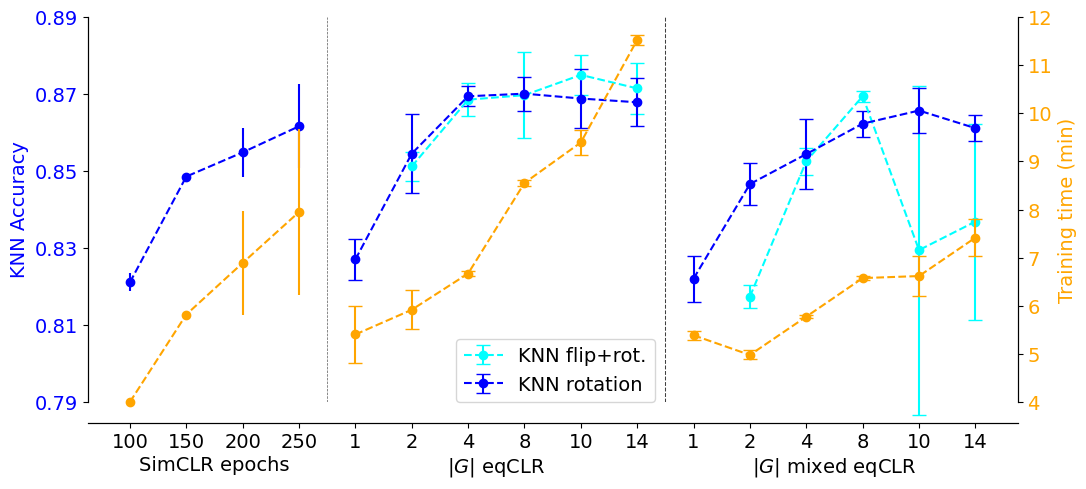

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fontsize = 14


labels_rot = [f'N={n}' for n in [1, 2, 4, 8, 10, 14]] 
labels_flips = [f'N={n}' for n in [2, 4, 8, 10, 14]] 

x_resnet = np.array(range(4))
x_rot = np.array(range(4, 10))
x_flips = np.array(range(5, 10))
x_mixed_rot = np.array(range(10, 16))
x_mixed_flips = np.array(range(11, 16))


# ResNet18 (no resize)
ax.errorbar(
    x_resnet,
    [blood_perf[f'ResNet18_{epochs}e']['KNN'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf[f'ResNet18_{epochs}e']['KNN_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='blue',
    zorder=-1
)
ax.axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.65, color='black', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_flips,
    [blood_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    capsize=5,
    color='cyan',
    label='KNN flip+rot.'
)
# eqResNet rot
ax.errorbar(
    x_rot,
    [blood_perf[f'eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='blue',
    label='KNN rotation'
)

ax.axvline(9.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed_flips,
    [blood_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    capsize=5,
    color='cyan',
    clip_on=False
)
# mixed eqResNet rot
ax.errorbar(
    x_mixed_rot,
    [blood_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    list(x_resnet) + list(x_rot) + list(x_mixed_rot)
)

xlabels = [1, 2, 4, 8, 10, 14]

ax.set_xticklabels(
    [100, 150, 200, 250] + xlabels + xlabels 
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax.set_ylim(0.79, 0.89)
ax.set_yticks([0.79, 0.81, 0.83, 0.85, 0.87, 0.89])

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    [blood_perf[f'ResNet18_{epochs}e']['time'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf[f'ResNet18_{epochs}e']['time_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='orange',
    clip_on=False
)

# eqResNet rot
ax2.errorbar(
    x_rot,
    [combined_time[f'eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time[f'eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed_rot,
    [combined_time[f'mixed_eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time[f'mixed_eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(4, 12)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 15))
ax2.spines['bottom'].set_position(('outward', 15))

ax.legend(frameon=True, loc='upper right', bbox_to_anchor=(0.62, 0.19), fontsize=fontsize)

ax.text(1.5, ax.get_ylim()[0] - 0.014, "SimCLR epochs", ha='center', va='top', fontsize=fontsize)
ax.text(6.5, ax.get_ylim()[0] - 0.014, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax.text(12.5, ax.get_ylim()[0] - 0.014, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)

## Bloodmnist (128)

In [ ]:
blood_perf_128 = {}

# Resnet
for epoch in [100, 150, 200, 250]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/bloodmnist/model_eval/C-1005_seed{rs}_resnet18_bloodmnist_128_no_resize_{epoch}epochs_eval.pkl'
        details_path = f'results_img129_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_128_no_resize_{epoch}epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

        blood_perf_128[f'ResNet18_{epoch}e'] = {}
        blood_perf_128[f'ResNet18_{epoch}e']['KNN'] = np.mean(knns)
        blood_perf_128[f'ResNet18_{epoch}e']['KNN_std'] = np.std(knns)
        blood_perf_128[f'ResNet18_{epoch}e']['time'] = np.mean(times)
        blood_perf_128[f'ResNet18_{epoch}e']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [1, 2, 4, 8, 10, 14]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf_128[f'eqResNet_N={n}'] = {}
    blood_perf_128[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf_128[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf_128[f'eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf_128[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8, 10, 14]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img129_crops/bloodmnist/model_eval/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img129_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf_128[f'eqResNet_N={n}_flips'] = {}
    blood_perf_128[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf_128[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf_128[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf_128[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [1, 2, 4, 8, 10, 14]:
    knns = []
    times = []

    for rs in range(3):
        eval_path = f'results_img129_crops/bloodmnist/model_eval/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_eval.pkl'
        details_path = f'results_img129_crops/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf_128[f'mixed_eqResNet_N={n}'] = {}
    blood_perf_128[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf_128[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    blood_perf_128[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    blood_perf_128[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8, 10, 14]:
    knns = []
    times = []
    for rs in range(3):
        eval_path1 = f'results_img129_crops/bloodmnist/model_eval/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_1000epochs_eval.pkl'
        details_path1 = f'results_img129_crops/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_1000epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    blood_perf_128[f'mixed_eqResNet_N={n}_flips'] = {}
    blood_perf_128[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    blood_perf_128[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    blood_perf_128[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    blood_perf_128[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

blood_perf_128['ResNet18'] = blood_perf_128['ResNet18_100e']
blood_perf_128_df = pd.DataFrame(blood_perf_128).T
display(blood_perf_128_df)


,KNN,KNN_std,time,time_std
ResNet18_100e,0.933061,0.008675,12.585715,0.031575
ResNet18_150e,0.964435,0.003344,19.466121,0.461096
ResNet18_200e,0.971646,0.002492,26.232943,0.183764
ResNet18_250e,0.977882,0.000729,32.973155,0.309550
eqResNet_N=1,0.937543,0.001553,14.759518,0.237853
eqResNet_N=2,0.950015,0.002351,21.296287,0.433063
eqResNet_N=4,0.968333,0.001102,26.734705,0.086146
eqResNet_N=8,0.961122,0.000861,43.481356,0.123749
eqResNet_N=10,0.955179,0.006325,51.090280,0.240430
eqResNet_N=14,0.947384,0.015202,63.341709,0.258628


In [ ]:
combined_time_128 = {}

# Resnet
for epoch in [100, 150, 200, 250]:
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/bloodmnist/model_details/C-1005_seed{rs}_resnet18_bloodmnist_128_no_resize_{epoch}epochs_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        combined_time_128[f'ResNet18_{epoch}e'] = {}
        combined_time_128[f'ResNet18_{epoch}e']['time'] = np.mean(times)
        combined_time_128[f'ResNet18_{epoch}e']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8, 10, 14]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img129_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img129_crops/bloodmnist/model_details/C-0001_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
                details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    combined_time_128[f'eqResNet_N={n}'] = {}
    combined_time_128[f'eqResNet_N={n}']['time'] = np.mean(times)
    combined_time_128[f'eqResNet_N={n}']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8, 10, 14]:
    knns = []
    times = []

    for rs in range(3):
        details_path1 = f'results_img129_crops/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_details.pkl'

        with open(details_path1, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img129_crops/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_1000epochs_details.pkl'

        with open(details_path, 'rb') as f:
                details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    combined_time_128[f'mixed_eqResNet_N={n}'] = {}
    combined_time_128[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    combined_time_128[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

combined_time_128['eqResNet_N=1'] = {}
combined_time_128['eqResNet_N=1']['time'] = blood_perf_128['eqResNet_N=1']['time']
combined_time_128['eqResNet_N=1']['time_std'] = blood_perf_128['eqResNet_N=1']['time_std']
combined_time_128['mixed_eqResNet_N=1'] = {}
combined_time_128['mixed_eqResNet_N=1']['time'] = blood_perf_128['mixed_eqResNet_N=1']['time']
combined_time_128['mixed_eqResNet_N=1']['time_std'] = blood_perf_128['mixed_eqResNet_N=1']['time_std']


combined_time_128_df = pd.DataFrame(combined_time_128).T
display(combined_time_128_df)

,time,time_std
ResNet18_100e,12.585715,0.031575
ResNet18_150e,19.466121,0.461096
ResNet18_200e,26.232943,0.183764
ResNet18_250e,32.973155,0.309550
eqResNet_N=2,21.464281,0.352408
eqResNet_N=4,26.751308,0.082852
eqResNet_N=8,43.509782,0.147810
eqResNet_N=10,51.058239,0.173862
eqResNet_N=14,63.264028,0.235202
mixed_eqResNet_N=2,19.340256,0.259862


Text(12.5, 0.8775526932759963, '$|G|$ mixed eqCLR')

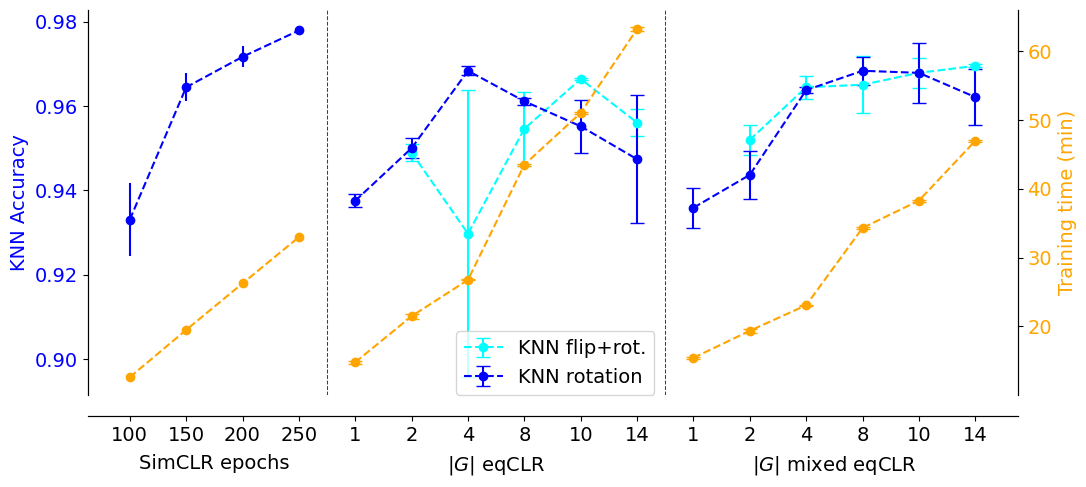

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fontsize = 14


labels_rot = [f'N={n}' for n in [1, 2, 4, 8, 10, 14]] # [f'N={n}' for n in range(1, 15)]
labels_flips = [f'N={n}' for n in [2, 4, 8, 10, 14]] # [f'N={n}' for n in range(2, 15, 2)]

x_resnet = np.array(range(4))
x_rot = np.array(range(4, 10))
x_flips = np.array(range(5, 10))
x_mixed_rot = np.array(range(10, 16))
x_mixed_flips = np.array(range(11, 16))


# ResNet18 (no resize)
ax.errorbar(
    x_resnet,
    [blood_perf_128[f'ResNet18_{epochs}e']['KNN'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf_128[f'ResNet18_{epochs}e']['KNN_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='blue',
    zorder=-1
)
ax.axvline(3.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_flips,
    [blood_perf_128[f'eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf_128[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    capsize=5,
    color='cyan',
    label='KNN flip+rot.'
)
# eqResNet rot
ax.errorbar(
    x_rot,
    [blood_perf_128[f'eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf_128[f'eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='blue',
    label='KNN rotation'
)

ax.axvline(9.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed_flips,
    [blood_perf_128[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf_128[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    capsize=5,
    color='cyan',
    clip_on=False
)
# mixed eqResNet rot
ax.errorbar(
    x_mixed_rot,
    [blood_perf_128[f'mixed_eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf_128[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    list(x_resnet) + list(x_rot) + list(x_mixed_rot)
)

xlabels = [1, 2, 4, 8, 10, 14]

ax.set_xticklabels(
    [100, 150, 200, 250] + xlabels + xlabels 
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    [blood_perf_128[f'ResNet18_{epochs}e']['time'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf_128[f'ResNet18_{epochs}e']['time_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='orange',
    clip_on=False
)

# eqResNet rot
ax2.errorbar(
    x_rot,
    [combined_time_128[f'eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time_128[f'eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed_rot,
    [combined_time_128[f'mixed_eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time_128[f'mixed_eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
# ax2.set_ylim(4, 12)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 15))
ax2.spines['bottom'].set_position(('outward', 15))

ax.legend(frameon=True, loc='upper right', bbox_to_anchor=(0.62, 0.19), fontsize=fontsize)

ax.text(1.5, ax.get_ylim()[0] - 0.014, "SimCLR epochs", ha='center', va='top', fontsize=fontsize)
ax.text(6.5, ax.get_ylim()[0] - 0.014, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax.text(12.5, ax.get_ylim()[0] - 0.014, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)


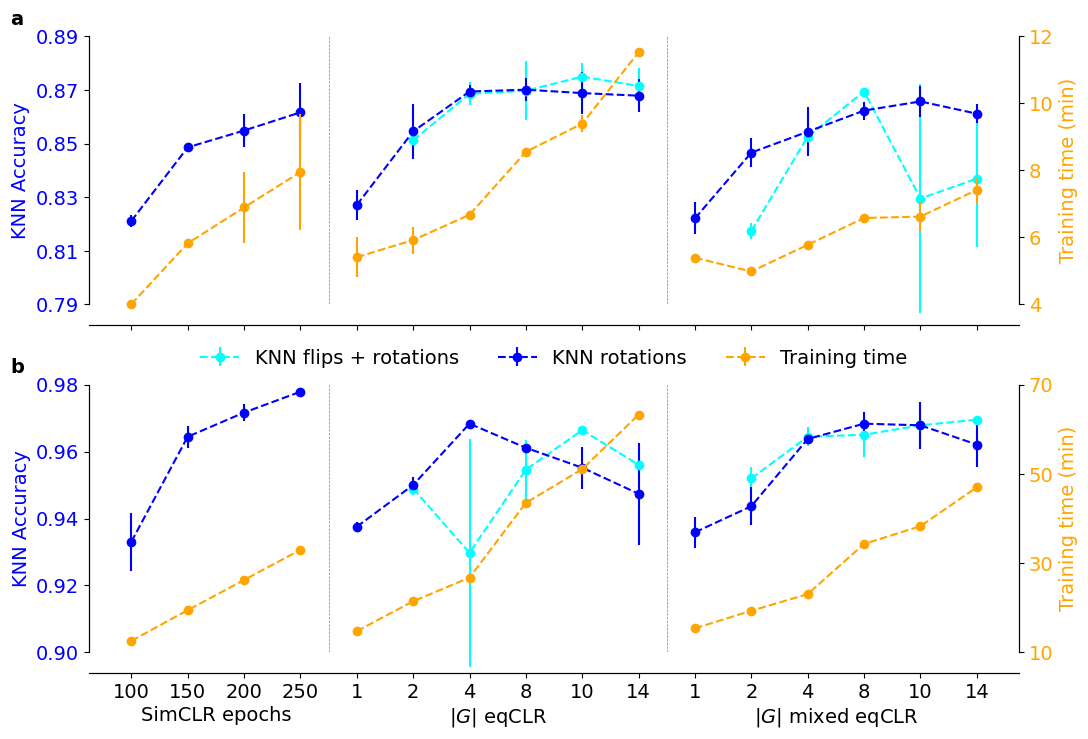

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'hspace': 0.3})

fontsize = 14

labels_rot = [f'N={n}' for n in [1, 2, 4, 8, 10, 14]] 
labels_flips = [f'N={n}' for n in [2, 4, 8, 10, 14]] 

x_resnet = np.array(range(4))
x_rot = np.array(range(4, 10))
x_flips = np.array(range(5, 10))
x_mixed_rot = np.array(range(10, 16))
x_mixed_flips = np.array(range(11, 16))

# time axis
ax2 = ax[0].twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    [blood_perf[f'ResNet18_{epochs}e']['time'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf[f'ResNet18_{epochs}e']['time_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='orange',
    clip_on=False,
    zorder=1,
    label='Training time'
)

# eqResNet rot
ax2.errorbar(
    x_rot,
    [combined_time[f'eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time[f'eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed_rot,
    [combined_time[f'mixed_eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time[f'mixed_eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    color='orange'
)

# performance axis
# ResNet18 (no resize)
ax[0].errorbar(
    x_resnet,
    [blood_perf[f'ResNet18_{epochs}e']['KNN'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf[f'ResNet18_{epochs}e']['KNN_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='blue',
    zorder=10,
)
ax[0].axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black', zorder=1)

# eqResNet rot+flips
ax[0].errorbar(
    x_flips,
    [blood_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    color='cyan',
    label='KNN flips + rotations'
)
# eqResNet rot
ax[0].errorbar(
    x_rot,
    [blood_perf[f'eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    color='blue',
    label='KNN rotations'
)

ax[0].axvline(9.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black', zorder=1)

# mixed eqResNet rot+flips
ax[0].errorbar(
    x_mixed_flips,
    [blood_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    color='cyan',
    clip_on=False
)
# mixed eqResNet rot
ax[0].errorbar(
    x_mixed_rot,
    [blood_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    color='blue'
)

ax[0].set_xticks(
    list(x_resnet) + list(x_rot) + list(x_mixed_rot)
)

xlabels = [1, 2, 4, 8, 10, 14]

ax[0].set_xticklabels(
    [100, 150, 200, 250] + xlabels + xlabels 
)

ax[0].set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax[0].tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax[0].set_ylim(0.79, 0.89)
ax[0].set_yticks([0.79, 0.81, 0.83, 0.85, 0.87, 0.89])

ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(4, 12)

ax[0].spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax[0].tick_params(axis='x', labelsize=fontsize)

ax[0].spines['bottom'].set_position(('outward', 15))
ax2.spines['bottom'].set_position(('outward', 15))

# get handles from both axes
h1, l1 = ax[0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax[0].legend(
    h1 + h2,
    l1 + l2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=fontsize,
    frameon=False,
    ncol=3
)

# plot 128 b)

# ResNet18 (no resize)
ax[1].errorbar(
    x_resnet,
    [blood_perf_128[f'ResNet18_{epochs}e']['KNN'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf_128[f'ResNet18_{epochs}e']['KNN_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='blue',
    zorder=-1
)
ax[1].axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black', zorder=1)

# eqResNet rot+flips
ax[1].errorbar(
    x_flips,
    [blood_perf_128[f'eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf_128[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    color='cyan',
    label='KNN flip+rot.',
    clip_on=False
)
# eqResNet rot
ax[1].errorbar(
    x_rot,
    [blood_perf_128[f'eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf_128[f'eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    color='blue',
    label='KNN rotation'
)

ax[1].axvline(9.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black', zorder=1)

# mixed eqResNet rot+flips
ax[1].errorbar(
    x_mixed_flips,
    [blood_perf_128[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_flips],
    yerr=[blood_perf_128[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_flips],
    fmt='--o',
    color='cyan',
    clip_on=False
)
# mixed eqResNet rot
ax[1].errorbar(
    x_mixed_rot,
    [blood_perf_128[f'mixed_eqResNet_{label}']['KNN'] for label in labels_rot],
    yerr=[blood_perf_128[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_rot],
    fmt='--o',
    color='blue'
)

ax[1].set_xticks(
    list(x_resnet) + list(x_rot) + list(x_mixed_rot)
)

xlabels = [1, 2, 4, 8, 10, 14]

ax[1].set_xticklabels(
    [100, 150, 200, 250] + xlabels + xlabels 
)

ax[1].set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax[1].tick_params(axis='y', labelcolor='blue', labelsize=fontsize)

# time axis
ax2 = ax[1].twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    [blood_perf_128[f'ResNet18_{epochs}e']['time'] for epochs in [100, 150, 200, 250]],
    yerr=[blood_perf_128[f'ResNet18_{epochs}e']['time_std'] for epochs in [100, 150, 200, 250]],
    fmt='--o',
    color='orange',
    clip_on=False
)

# eqResNet rot
ax2.errorbar(
    x_rot,
    [combined_time_128[f'eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time_128[f'eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed_rot,
    [combined_time_128[f'mixed_eqResNet_{label}']['time'] for label in labels_rot],
    yerr=[combined_time_128[f'mixed_eqResNet_{label}']['time_std'] for label in labels_rot],
    fmt='--o',
    color='orange'
)

ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(10, 70)
ax2.set_yticks([10, 30, 50, 70])
ax[1].set_ylim(0.9, 0.98)

ax[1].spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax[1].tick_params(axis='x', labelsize=fontsize)

ax[1].spines['bottom'].set_position(('outward', 15))
ax2.spines['bottom'].set_position(('outward', 15))


ax[1].text(1.5, ax[1].get_ylim()[0] - 0.016, "SimCLR epochs", ha='center', va='top', fontsize=fontsize)
ax[1].text(6.5, ax[1].get_ylim()[0] - 0.016, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax[1].text(12.5, ax[1].get_ylim()[0] - 0.016, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)

# a) and b) label
ax[0].text(-0.085, 1.1, 'a', transform=ax[0].transAxes, fontsize=fontsize, fontweight='bold', va='top')
ax[1].text(-0.085, 1.1, 'b', transform=ax[1].transAxes, fontsize=fontsize, fontweight='bold', va='top')

# save figure
fig.savefig('figures/bloodmnist_performance.pdf', bbox_inches='tight')


# Cifar10

# 

In [15]:
cifar_perf = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / 60)

cifar_perf['ResNet18'] = {}
cifar_perf['ResNet18']['KNN'] = np.mean(knns)
cifar_perf['ResNet18']['KNN_std'] = np.std(knns)
cifar_perf['ResNet18']['time'] = np.mean(times)
cifar_perf['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in [1, 2]:
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf[f'eqResNet_N={n}'] = {}
    cifar_perf[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    cifar_perf[f'eqResNet_N={n}']['time'] = np.mean(times)
    cifar_perf[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in [1,2]:
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf[f'eqResNet_N={n}_flips'] = {}
    cifar_perf[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    cifar_perf[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    cifar_perf[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    cifar_perf[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(2):
        eval_path1 = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path1 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'
        
        eval_path2 = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path2 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        try:
            with open(eval_path1, 'rb') as f:
                eval = pickle.load(f)
        except FileNotFoundError:
            with open(eval_path2, 'rb') as f:
                eval = pickle.load(f)

        try:
            with open(details_path1, 'rb') as f:
                details = pickle.load(f)
        except FileNotFoundError:
            with open(details_path2, 'rb') as f:
                details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf[f'mixed_eqResNet_N={n}'] = {}
    cifar_perf[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    cifar_perf[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    cifar_perf[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path1 = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path1 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'
        eval_path2 = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_eval.pkl'
        details_path2 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        try:
            with open(eval_path1, 'rb') as f:
                eval = pickle.load(f)
        except FileNotFoundError:
            with open(eval_path2, 'rb') as f:
                eval = pickle.load(f)

        try:
            with open(details_path1, 'rb') as f:
                details = pickle.load(f)
        except FileNotFoundError:
            with open(details_path2, 'rb') as f:
                details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf[f'mixed_eqResNet_N={n}_flips'] = {}
    cifar_perf[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    cifar_perf[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    cifar_perf[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    cifar_perf[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

cifar_perf_df = pd.DataFrame(cifar_perf).T
display(cifar_perf_df)


,KNN,KNN_std,time,time_std
ResNet18,0.715833,0.002763,11.395181,0.229860
eqResNet_N=2,0.698000,0.000700,16.366802,0.033882
eqResNet_N=4,0.706700,0.000900,17.576462,0.000947
eqResNet_N=8,0.712250,0.000050,24.710368,0.103579
eqResNet_N=2_flips,0.766950,0.001450,17.041837,0.306620
eqResNet_N=4_flips,0.741350,0.003450,17.919430,0.272438
eqResNet_N=8_flips,0.738250,0.001250,24.753647,0.121066
mixed_eqResNet_N=2,0.732550,0.001550,13.320273,0.474967
mixed_eqResNet_N=4,0.754050,0.002450,14.979231,0.058051
mixed_eqResNet_N=8,0.752750,0.001550,16.933084,0.196233


In [16]:
cifar_time = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    times = []
    for rs in [1, 2]:
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    cifar_time[f'eqResNet_N={n}'] = {}
    cifar_time[f'eqResNet_N={n}']['time'] = np.mean(times)
    cifar_time[f'eqResNet_N={n}']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    times = []
    for rs in range(2):
        details_path1 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'
        
        details_path2 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_details.pkl'

        try:
            with open(details_path1, 'rb') as f:
                details = pickle.load(f)
        except FileNotFoundError:
            with open(details_path2, 'rb') as f:
                details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path1 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'
        details_path2 = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_details.pkl'

        try:
            with open(details_path1, 'rb') as f:
                details = pickle.load(f)
        except FileNotFoundError:
            with open(details_path2, 'rb') as f:
                details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    cifar_time[f'mixed_eqResNet_N={n}'] = {}
    cifar_time[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    cifar_time[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

cifar_time_df = pd.DataFrame(cifar_time).T
display(cifar_time_df)


,time,time_std
eqResNet_N=2,16.704319,0.401870
eqResNet_N=4,17.747946,0.257911
eqResNet_N=8,24.732008,0.114721
mixed_eqResNet_N=2,13.397898,0.437936
mixed_eqResNet_N=4,15.014639,0.059365
mixed_eqResNet_N=8,16.937761,0.264815


In [17]:
cifar_perf_all = {}

# Resnet
cifar_perf_all['SimCLR'] = {}
for rs in range(3):
    eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    cifar_perf_all['SimCLR'][f'seed{rs}'] = {}
    cifar_perf_all['SimCLR'][f'seed{rs}'] = eval
    cifar_perf_all['SimCLR'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR
for n in [2, 4, 8]:
    cifar_perf_all[f'eqCLR $C_{n}$'] = {}
    for rs in [1, 2]:
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = {}
        cifar_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = eval
        cifar_perf_all[f'eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    cifar_perf_all[f'eqCLR $D_{n}$'] = {}
    for rs in [1,2]:
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}'] = eval
        cifar_perf_all[f'eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR
for n in [2, 4, 8]:
    cifar_perf_all[f'mixed eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}'] = eval
        cifar_perf_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    cifar_perf_all[f'mixed eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}'] = eval
        cifar_perf_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

In [80]:
cifar_perf_mean = {}

for model_name, seeds in cifar_perf_all.items():
    cifar_perf_mean[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        cifar_perf_mean[model_name][eval_key] = float(np.mean(values))

cifar_perf_mean_df = pd.DataFrame(cifar_perf_mean).T
display(cifar_perf_mean_df)

,euclidean,cosine,logistic_regression,linear_accuracy,linear_accuracy_rep,linear_accuracy_aug,time
SimCLR,0.715833,0.718233,0.748733,0.753133,0.748400,0.741933,11.395181
eqCLR $C_2$,0.698000,0.701600,0.731250,0.735750,0.732300,0.725800,16.366802
eqCLR $C_4$,0.706700,0.711700,0.734450,0.736650,0.733600,0.727200,17.576462
eqCLR $C_8$,0.712250,0.719300,0.739950,0.738900,0.736750,0.734200,24.710368
eqCLR $D_2$,0.766950,0.767750,0.788200,0.793450,0.788300,0.784850,17.041837
eqCLR $D_4$,0.741350,0.745150,0.766300,0.768500,0.764450,0.763500,17.919430
eqCLR $D_8$,0.738250,0.743100,0.765250,0.765000,0.763400,0.759250,24.753647
mixed eqCLR $C_2$,0.733233,0.735833,0.763233,0.767000,0.763233,0.756533,15.034296
mixed eqCLR $C_4$,0.753567,0.756200,0.782700,0.785200,0.783467,0.777967,14.999424
mixed eqCLR $C_8$,0.754300,0.759933,0.786833,0.791100,0.787567,0.785667,17.038980


Text(9.5, 0.6852450000000001, 'mixed eqCLR\n(rot+flips)')

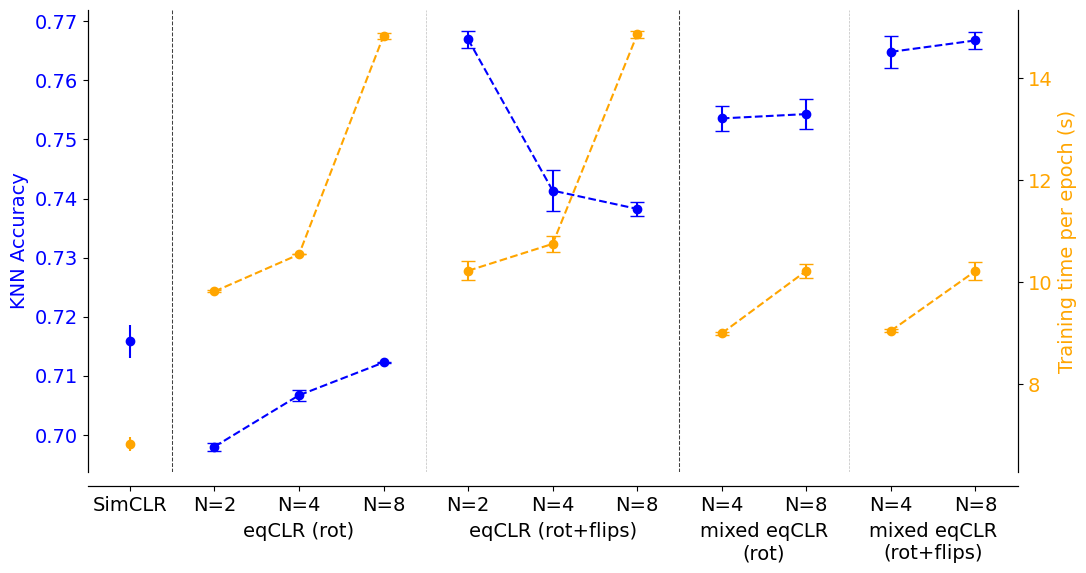

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fontsize = 14

labels_eq = ['N=2', 'N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2, 3])
x_eq2 = np.array([4, 5, 6])
x_mixed1 = np.array([7, 8])
x_mixed2 = np.array([9, 10])

# ResNet18
ax.errorbar(
    x_resnet,
    cifar_perf['ResNet18']['KNN'],
    yerr=cifar_perf['ResNet18']['KNN_std'],
    fmt='o',
    color='blue'
)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet rot
ax.errorbar(
    x_eq1,
    [cifar_perf[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_eq2,
    [cifar_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(6.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot
ax.errorbar(
    x_mixed1,
    [cifar_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(8.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed2,
    [cifar_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    [x_resnet] + list(x_eq1) + list(x_eq2) + list(x_mixed1) + list(x_mixed2)
)

ax.set_xticklabels(
    ['SimCLR'] + labels_eq + labels_eq + labels_mixed + labels_mixed
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    cifar_perf['ResNet18']['time'],
    yerr=cifar_perf['ResNet18']['time_std'],
    fmt='o',
    color='orange'
)

# eqResNet rot
ax2.errorbar(
    x_eq1,
    [cifar_perf[f'eqResNet_{label}']['time'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# eqResNet rot+flips
ax2.errorbar(
    x_eq2,
    [cifar_perf[f'eqResNet_{label}_flips']['time'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}_flips']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed1,
    [cifar_perf[f'mixed_eqResNet_{label}']['time'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot+flips
ax2.errorbar(
    x_mixed2,
    [cifar_perf[f'mixed_eqResNet_{label}_flips']['time'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}_flips']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
#ax2.set_ylim(5, 40)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

ax.text(2, ax.get_ylim()[0] - 0.0085, "eqCLR (rot)", ha='center', va='top', fontsize=fontsize)
ax.text(5, ax.get_ylim()[0] - 0.0085, "eqCLR (rot+flips)", ha='center', va='top', fontsize=fontsize)
ax.text(7.5, ax.get_ylim()[0] - 0.0085, "mixed eqCLR\n(rot)", ha='center', va='top', fontsize=fontsize)
ax.text(9.5, ax.get_ylim()[0] - 0.0085, "mixed eqCLR\n(rot+flips)", ha='center', va='top', fontsize=fontsize)

## No maxpool

In [18]:
cifar_perf_nm = {}

knns = []
times = []

# Resnet
for rs in range(3):
    eval_path = f'results_img33_crops/cifar10/model_eval/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/cifar10/model_details/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    knns.append(eval['euclidean'][10])
    times.append(details['Training time w/o evaluation'] / 60)

cifar_perf_nm['ResNet18'] = {}
cifar_perf_nm['ResNet18']['KNN'] = np.mean(knns)
cifar_perf_nm['ResNet18']['KNN_std'] = np.std(knns)
cifar_perf_nm['ResNet18']['time'] = np.mean(times)
cifar_perf_nm['ResNet18']['time_std'] = np.std(times)

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf_nm[f'eqResNet_N={n}'] = {}
    cifar_perf_nm[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf_nm[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)
    cifar_perf_nm[f'eqResNet_N={n}']['time'] = np.mean(times)
    cifar_perf_nm[f'eqResNet_N={n}']['time_std'] = np.std(times)

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf_nm[f'eqResNet_N={n}_flips'] = {}
    cifar_perf_nm[f'eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    cifar_perf_nm[f'eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    cifar_perf_nm[f'eqResNet_N={n}_flips']['time'] = np.mean(times)
    cifar_perf_nm[f'eqResNet_N={n}_flips']['time_std'] = np.std(times)


# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(2):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)
                
        print(f"Processed seed {rs} for mixed eqCLR N={n}, epochs={details['N_EPOCHS']}")


    cifar_perf_nm[f'mixed_eqResNet_N={n}'] = {}
    cifar_perf_nm[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf_nm[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)
    cifar_perf_nm[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    cifar_perf_nm[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR flips
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(2):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / 60)

    cifar_perf_nm[f'mixed_eqResNet_N={n}_flips'] = {}
    cifar_perf_nm[f'mixed_eqResNet_N={n}_flips']['KNN'] = np.mean(knns)
    cifar_perf_nm[f'mixed_eqResNet_N={n}_flips']['KNN_std'] = np.std(knns)
    cifar_perf_nm[f'mixed_eqResNet_N={n}_flips']['time'] = np.mean(times)
    cifar_perf_nm[f'mixed_eqResNet_N={n}_flips']['time_std'] = np.std(times)

cifar_perf_nm_df = pd.DataFrame(cifar_perf_nm).T
display(cifar_perf_nm_df)


Processed seed 0 for mixed eqCLR N=2, epochs=100
Processed seed 1 for mixed eqCLR N=2, epochs=100
Processed seed 0 for mixed eqCLR N=4, epochs=100
Processed seed 1 for mixed eqCLR N=4, epochs=100
Processed seed 0 for mixed eqCLR N=8, epochs=100
Processed seed 1 for mixed eqCLR N=8, epochs=100


,KNN,KNN_std,time,time_std
ResNet18,0.822067,0.001014,20.646525,0.109636
eqResNet_N=2,0.806700,0.001388,49.080047,0.219160
eqResNet_N=4,0.803900,0.002790,65.372204,0.222519
eqResNet_N=8,0.803867,0.001919,124.680842,0.213591
eqResNet_N=2_flips,0.853000,0.002499,48.870558,0.511997
eqResNet_N=4_flips,0.836133,0.002611,65.262815,0.290525
eqResNet_N=8_flips,0.826433,0.001678,124.864991,0.399831
mixed_eqResNet_N=2,0.827550,0.000750,38.221544,0.296128
mixed_eqResNet_N=4,0.819450,0.000350,50.077177,0.127627
mixed_eqResNet_N=8,0.820850,0.001350,86.110034,0.036052


In [19]:
cifar_time_nm = {}

# equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(3):
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    cifar_time_nm[f'eqResNet_N={n}'] = {}
    cifar_time_nm[f'eqResNet_N={n}']['time'] = np.mean(times)
    cifar_time_nm[f'eqResNet_N={n}']['time_std'] = np.std(times)

# mixed equivariant SimCLR
for n in [2, 4, 8]:
    knns = []
    times = []
    for rs in range(2):
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        times.append(details['Training time w/o evaluation'] / 60)

    cifar_time_nm[f'mixed_eqResNet_N={n}'] = {}
    cifar_time_nm[f'mixed_eqResNet_N={n}']['time'] = np.mean(times)
    cifar_time_nm[f'mixed_eqResNet_N={n}']['time_std'] = np.std(times)

cifar_time_nm_df = pd.DataFrame(cifar_time_nm).T
display(cifar_time_nm_df)


,time,time_std
eqResNet_N=2,48.975302,0.407502
eqResNet_N=4,65.317509,0.264483
eqResNet_N=8,124.772916,0.333498
mixed_eqResNet_N=2,38.342935,0.342430
mixed_eqResNet_N=4,50.031368,0.136193
mixed_eqResNet_N=8,86.113654,0.100060


In [127]:
models = {}
for n in [2, 4, 8]:
    knns = []
    times = []
    models[f'eqCLR_N={n}'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        models[f'eqCLR_N={n}'][f'seed{rs}'] = {}
        models[f'eqCLR_N={n}'][f'seed{rs}'] = details['Model structure']

        knns.append(eval['euclidean'][10])
        times.append(details['Training time w/o evaluation'] / details['N_EPOCHS'])
        print(f"Processed seed {rs} for eqCLR with flips N={n}, epochs={details['N_EPOCHS']}")

Processed seed 0 for eqCLR with flips N=2, epochs=100
Processed seed 1 for eqCLR with flips N=2, epochs=100
Processed seed 2 for eqCLR with flips N=2, epochs=100
Processed seed 0 for eqCLR with flips N=4, epochs=100
Processed seed 1 for eqCLR with flips N=4, epochs=100
Processed seed 2 for eqCLR with flips N=4, epochs=100
Processed seed 0 for eqCLR with flips N=8, epochs=100
Processed seed 1 for eqCLR with flips N=8, epochs=100
Processed seed 2 for eqCLR with flips N=8, epochs=100


In [81]:
cifar_perf_nm_all = {}

# Resnet
cifar_perf_nm_all['SimCLR'] = {}
for rs in range(3):
    eval_path = f'results_img33_crops/cifar10/model_eval/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_100epochs_eval.pkl'
    details_path = f'results_img33_crops/cifar10/model_details/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_100epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    cifar_perf_nm_all['SimCLR'][f'seed{rs}'] = {}
    cifar_perf_nm_all['SimCLR'][f'seed{rs}'] = eval
    cifar_perf_nm_all['SimCLR'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR
for n in [2, 4, 8]:
    cifar_perf_nm_all[f'eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_nm_all[f'eqCLR $C_{n}$'][f'seed{rs}'] = eval
        cifar_perf_nm_all[f'eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# equivariant SimCLR with flips
for n in [2, 4, 8]:
    cifar_perf_nm_all[f'eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0001_seed{rs}_cifar10_no_maxpool-eqCLR_resnet18_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_nm_all[f'eqCLR $D_{n}$'][f'seed{rs}'] = eval
        cifar_perf_nm_all[f'eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR
for n in [4, 8]:
    cifar_perf_nm_all[f'mixed eqCLR $C_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_nm_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}'] = eval
        cifar_perf_nm_all[f'mixed eqCLR $C_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60

# mixed equivariant SimCLR flips
for n in [4, 8]:
    cifar_perf_nm_all[f'mixed eqCLR $D_{n}$'] = {}
    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/model_eval/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_eval.pkl'
        details_path = f'results_img33_crops/cifar10/model_details/C-0002_seed{rs}_cifar10_no_maxpool-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_100epochs_b512_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_nm_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}'] = eval
        cifar_perf_nm_all[f'mixed eqCLR $D_{n}$'][f'seed{rs}']['time'] = details['Training time w/o evaluation'] / 60



In [82]:
cifar_perf_nm_mean = {}

for model_name, seeds in cifar_perf_nm_all.items():
    cifar_perf_nm_mean[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        cifar_perf_nm_mean[model_name][eval_key] = float(np.mean(values))

cifar_perf_nm_mean_df = pd.DataFrame(cifar_perf_nm_mean).T
display(cifar_perf_nm_mean_df)


,euclidean,cosine,logistic_regression,linear_accuracy,linear_accuracy_rep,linear_accuracy_aug,time
SimCLR,0.822067,0.832600,0.850500,0.856967,0.851900,0.847967,20.646525
eqCLR $C_2$,0.806700,0.813633,0.834867,0.838733,0.835367,0.832200,49.080047
eqCLR $C_4$,0.803900,0.808733,0.833000,0.835267,0.832200,0.833500,65.372204
eqCLR $C_8$,0.803867,0.809733,0.832133,0.834533,0.831600,0.830400,124.680842
eqCLR $D_2$,0.853000,0.862867,0.877400,0.880567,0.877067,0.874500,48.870558
eqCLR $D_4$,0.836133,0.845500,0.862333,0.864933,0.861300,0.860367,65.262815
eqCLR $D_8$,0.826433,0.836467,0.855367,0.855900,0.854567,0.853733,124.864991
mixed eqCLR $C_4$,0.818933,0.824633,0.845533,0.854667,0.846667,0.845633,50.047220
mixed eqCLR $C_8$,0.820667,0.828733,0.847800,0.854200,0.849633,0.846833,86.907751
mixed eqCLR $D_4$,0.828333,0.834200,0.854000,0.859767,0.855000,0.853467,49.903861


Text(9.5, 0.7898900504026752, 'mixed eqCLR\n(rot+flips)')

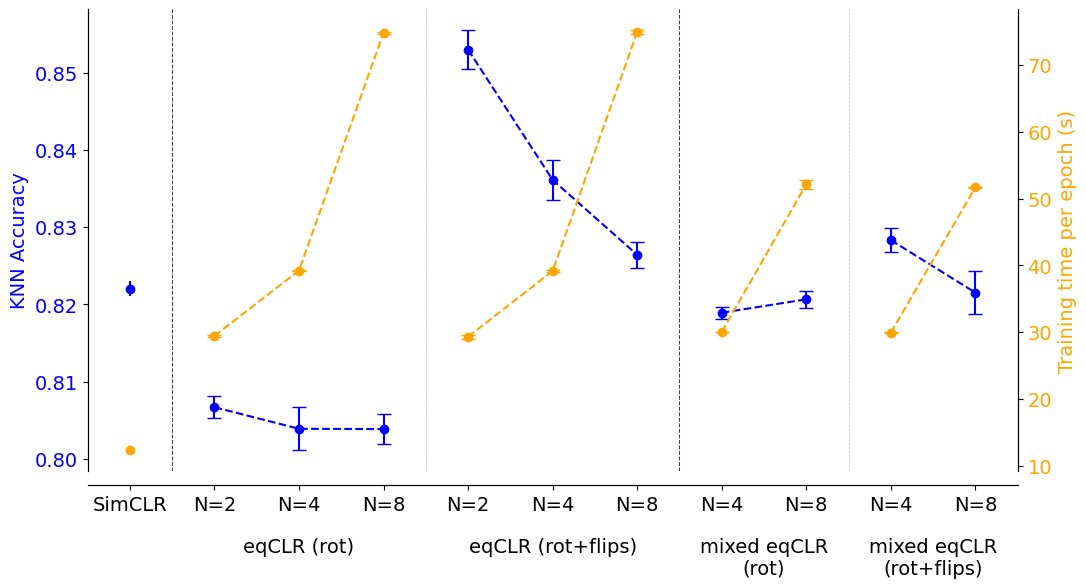

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fontsize = 14

labels_eq = ['N=2', 'N=4', 'N=8']
labels_mixed = ['N=4', 'N=8']

x_resnet = 0
x_eq1 = np.array([1, 2, 3])
x_eq2 = np.array([4, 5, 6])
x_mixed1 = np.array([7, 8])
x_mixed2 = np.array([9, 10])

# ResNet18
ax.errorbar(
    x_resnet,
    cifar_perf['ResNet18']['KNN'],
    yerr=cifar_perf['ResNet18']['KNN_std'],
    fmt='o',
    color='blue'
)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# eqResNet rot
ax.errorbar(
    x_eq1,
    [cifar_perf[f'eqResNet_{label}']['KNN'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# eqResNet rot+flips
ax.errorbar(
    x_eq2,
    [cifar_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(6.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

# mixed eqResNet rot
ax.errorbar(
    x_mixed1,
    [cifar_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)
ax.axvline(8.5, linestyle='--', linewidth=0.5, alpha=0.5, color='gray', zorder=1)

# mixed eqResNet rot+flips
ax.errorbar(
    x_mixed2,
    [cifar_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='blue'
)

ax.set_xticks(
    [x_resnet] + list(x_eq1) + list(x_eq2) + list(x_mixed1) + list(x_mixed2)
)

ax.set_xticklabels(
    ['SimCLR'] + labels_eq + labels_eq + labels_mixed + labels_mixed
)

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)

# time axis
ax2 = ax.twinx()

# ResNet18
ax2.errorbar(
    x_resnet,
    cifar_perf['ResNet18']['time'],
    yerr=cifar_perf['ResNet18']['time_std'],
    fmt='o',
    color='orange'
)

# eqResNet rot
ax2.errorbar(
    x_eq1,
    [cifar_perf[f'eqResNet_{label}']['time'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# eqResNet rot+flips
ax2.errorbar(
    x_eq2,
    [cifar_perf[f'eqResNet_{label}_flips']['time'] for label in labels_eq],
    yerr=[cifar_perf[f'eqResNet_{label}_flips']['time_std'] for label in labels_eq],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot
ax2.errorbar(
    x_mixed1,
    [cifar_perf[f'mixed_eqResNet_{label}']['time'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

# mixed eqResNet rot+flips
ax2.errorbar(
    x_mixed2,
    [cifar_perf[f'mixed_eqResNet_{label}_flips']['time'] for label in labels_mixed],
    yerr=[cifar_perf[f'mixed_eqResNet_{label}_flips']['time_std'] for label in labels_mixed],
    fmt='--o',
    capsize=5,
    color='orange'
)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
#ax2.set_ylim(5, 40)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

ax.text(2, ax.get_ylim()[0] - 0.0085, "eqCLR (rot)", ha='center', va='top', fontsize=fontsize)
ax.text(5, ax.get_ylim()[0] - 0.0085, "eqCLR (rot+flips)", ha='center', va='top', fontsize=fontsize)
ax.text(7.5, ax.get_ylim()[0] - 0.0085, "mixed eqCLR\n(rot)", ha='center', va='top', fontsize=fontsize)
ax.text(9.5, ax.get_ylim()[0] - 0.0085, "mixed eqCLR\n(rot+flips)", ha='center', va='top', fontsize=fontsize)

# combined

In [20]:
data_all = {
    "BloodMNIST":{
        28: {'perf': blood_perf, 'time': combined_time},
        128: {'perf': blood_perf_128, 'time': combined_time_128},
    },
    "PathMNIST":{
        28: {'perf': path_perf, 'time': path_time},
        128: {'perf': path128_perf, 'time': path128_time},
    },
    "DermaMNIST":{
        28: {'perf': derma_perf, 'time': derma_time},
        128: {'perf': derma128_perf, 'time': derma128_time},
    },
    "CIFAR10":{
        32: {'perf': cifar_perf, 'time': cifar_time},
        'no_maxpool': {'perf': cifar_perf_nm, 'time': cifar_time_nm},
    }
}

/scratch_local/bep071-2577413/tmp/ipykernel_3398883/1348061769.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


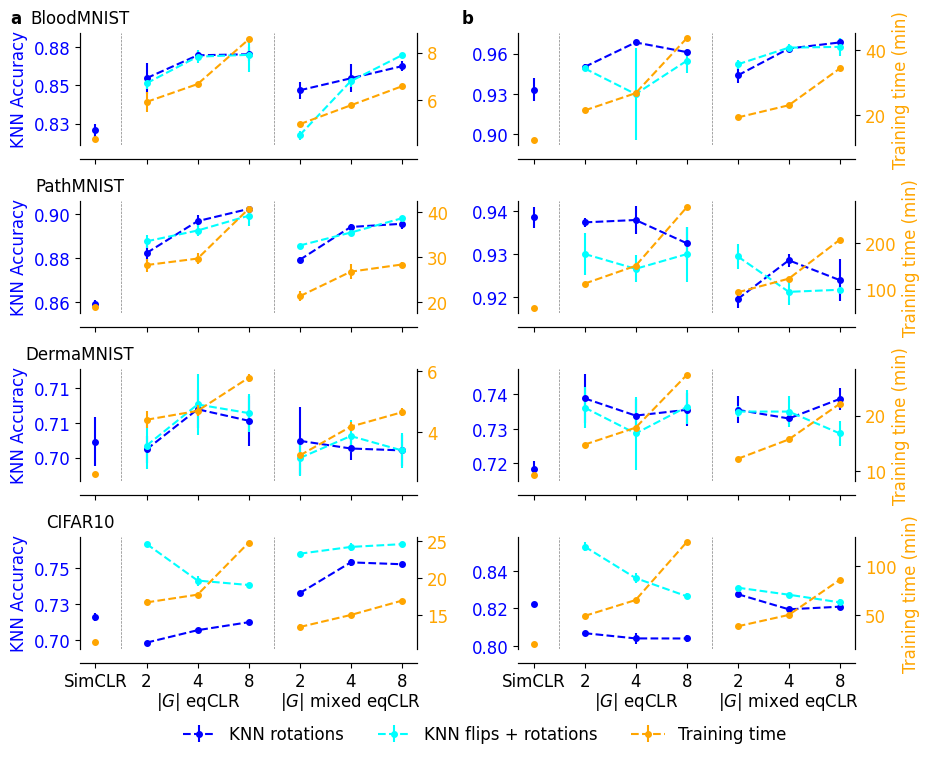

In [25]:
fig, ax = plt.subplots(4, 2, figsize=(10, 8), gridspec_kw={'hspace': 0.5, 'wspace': 0.3}, sharex='col')

fontsize=12
markersize=4
labels = [f'N={n}' for n in [2, 4, 8]] 

x_resnet = np.array([0])
x_eqresnet = np.array([1, 2, 3])
x_mixed = np.array([4, 5, 6])

for i, dataset in enumerate(data_all.keys()):
    for j, size in enumerate(data_all[dataset].keys()):

        data_perf = data_all[dataset][size]['perf']
        data_time = data_all[dataset][size]['time']

        # header
        if j == 0:
            ax[i, j].text(0, 1.05, dataset, transform=ax[i, j].transAxes, ha='center', va='bottom', fontsize=fontsize)
        # Resnet
        ax[i, j].errorbar(
            x_resnet,
            data_perf[f'ResNet18']['KNN'],
            yerr=data_perf[f'ResNet18']['KNN_std'],
            fmt='--o',
            color='blue',
            zorder=-1,
            clip_on=False,
            markersize=markersize
        )
        ax[i, j].axvline(0.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black')

        # eqCLR rot
        ax[i, j].errorbar(
            x_eqresnet,
            [data_perf[f'eqResNet_{label}']['KNN'] for label in labels],
            yerr=[data_perf[f'eqResNet_{label}']['KNN_std'] for label in labels],
            fmt='--o',
            color='blue',
            label='KNN rotations',
            clip_on=False,
            markersize=markersize
        )

        # eqCLR fips+rot
        ax[i, j].errorbar(
            x_eqresnet,
            [data_perf[f'eqResNet_{label}_flips']['KNN'] for label in labels],
            yerr=[data_perf[f'eqResNet_{label}_flips']['KNN_std'] for label in labels],
            fmt='--o',
            color='cyan',
            label='KNN flips + rotations',
            clip_on=False,
            markersize=markersize
        )
        ax[i, j].axvline(3.5, linestyle='--', linewidth=0.5, alpha=0.5, color='black')

        # mixed eqCLR rot
        ax[i, j].errorbar(
            x_mixed,
            [data_perf[f'mixed_eqResNet_{label}']['KNN'] for label in labels],
            yerr=[data_perf[f'mixed_eqResNet_{label}']['KNN_std'] for label in labels],
            fmt='--o',
            color='blue',
            clip_on=False,
            markersize=markersize
        )
        # mixed eqCLR flips
        ax[i, j].errorbar(
            x_mixed,
            [data_perf[f'mixed_eqResNet_{label}_flips']['KNN'] for label in labels],
            yerr=[data_perf[f'mixed_eqResNet_{label}_flips']['KNN_std'] for label in labels],
            fmt='--o',
            color='cyan',
            clip_on=False,
            markersize=markersize
        )

        ax[i, j].set_xticks(
            list(x_resnet) + list(x_eqresnet) + list(x_mixed)
        )
        ax[i, j].set_xticklabels(
            ['SimCLR', 2, 4, 8, 2, 4, 8]
        )
        if size == 28 or size == 32:
            ax[i, j].set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
        ax[i, j].tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
        # ax.set_ylim(0.79, 0.89)
        # ax.set_yticks([0.79, 0.81, 0.83, 0.85, 0.87, 0.89])

        # time axis
        ax2 = ax[i, j].twinx()
        ax2.errorbar(
            x_resnet,
            data_perf[f'ResNet18']['time'],
            yerr=data_perf[f'ResNet18']['time_std'],
            fmt='--o',
            color='orange',
            zorder=-1,
            clip_on=False,
            label='Training time',
            markersize=markersize
        )

        ax2.errorbar(
            x_eqresnet,
            [data_time[f'eqResNet_{label}']['time'] for label in labels],
            yerr=[data_time[f'eqResNet_{label}']['time_std'] for label in labels],
            fmt='--o',
            color='orange',
            clip_on=False,
            markersize=markersize
        )

        ax2.errorbar(
            x_mixed,
            [data_time[f'mixed_eqResNet_{label}']['time'] for label in labels],
            yerr=[data_time[f'mixed_eqResNet_{label}']['time_std'] for label in labels],
            fmt='--o',
            color='orange',
            clip_on=False,
            markersize=markersize
        )


        if size == 128 or size == 'no_maxpool':
            ax2.set_ylabel('Training time (min)', color='orange', fontsize=fontsize)

        ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
        ax[i, j].spines['top'].set_visible(False)
        ax2.spines['top'].set_visible(False)
        ax[i, j].tick_params(axis='x', labelsize=fontsize)
        ax[i, j].spines['bottom'].set_position(('outward', 10))
        ax2.spines['bottom'].set_position(('outward', 10))

        ax[i, j].yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
        ax[i,j].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


# column label a and b
ax[3, 0].text(2, ax[3, 0].get_ylim()[0] - 0.029, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax[3, 0].text(5, ax[3, 0].get_ylim()[0] - 0.029, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)
ax[3, 1].text(2, ax[3, 1].get_ylim()[0] - 0.022, r"$|G|$ eqCLR", ha='center', va='top', fontsize=fontsize)
ax[3, 1].text(5, ax[3, 1].get_ylim()[0] - 0.022, r"$|G|$ mixed eqCLR", ha='center', va='top', fontsize=fontsize)

# get handles from both axes
h1, l1 = ax[-1, -1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax[-1, -1].legend(
    h1 + h2,
    l1 + l2,
    loc='upper center',
    bbox_to_anchor=(-0.1, -0.55),
    fontsize=fontsize,
    frameon=False,
    ncol=3
)
# ax[-1, -1].legend(loc='upper center', bbox_to_anchor=(-0.1, -0.55), fontsize=fontsize, frameon=False, ncol=2)
ax[0, 0].text(-0.19, 1.05, 'a', transform=ax[0, 0].transAxes, ha='center', va='bottom', fontsize=fontsize, fontweight='bold')
ax[0, 1].text(-0.15, 1.05, 'b', transform=ax[0, 1].transAxes, ha='center', va='bottom', fontsize=fontsize, fontweight='bold')


plt.tight_layout()

# save figure
plt.savefig('figures/performances_all.pdf', bbox_inches='tight')